# 03 — Structural comparison: sperm whale codas vs Rigveda

Compares timing/sequence statistics from the two corpora against three null
models per side. The goal is **not** to argue that whale codas mean anything
Vedic; it is to ask whether the structural features of one corpus look more
like those of the other than either looks like its own surrogate.

Sections:

1. Load corpora.
2. Build whale sequences and Vedic sequences (one per stanza pāda).
3. Generate three surrogate variants per corpus.
4. Pooled inter-onset-interval (IOI) distributions: KS test + Cohen's d.
5. n-gram entropy table (n=2, n=3) across real and surrogate variants.
6. Mean lag-k autocorrelation comparison.
7. Honest verdict.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sps

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from swp import features, stats as swstats
from swp.io import DATA_PROCESSED, FIGURES

FIGURES.mkdir(exist_ok=True)
RNG = np.random.default_rng(20260501)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140


## 1. Load corpora

In [2]:
codas = pd.read_parquet(DATA_PROCESSED / "whale_codas.parquet")
vedic = pd.read_parquet(DATA_PROCESSED / "vedic_syllables.parquet")

print(f"Whale codas: {len(codas):,} rows; sources={dict(codas['source_dataset'].value_counts())}")
print(f"  n_clicks  median={int(codas['n_clicks'].median())} "
      f"min={int(codas['n_clicks'].min())} max={int(codas['n_clicks'].max())}")
print(f"  total_duration mean={codas['total_duration'].mean():.3f}s "
      f"median={codas['total_duration'].median():.3f}s")
print()
print(f"Vedic syllables: {len(vedic):,} rows across {vedic['verse_id'].nunique():,} pādas")
print(f"  weight: {dict(vedic['weight'].value_counts())}")
print(f"  meter labels: {vedic['meter_label'].nunique()} bins")


Whale codas: 12,559 rows; sources={'ceti': 12559}
  n_clicks  median=5 min=1 max=29
  total_duration mean=0.862s median=0.896s

Vedic syllables: 374,897 rows across 39,717 pādas
  weight: {'G': np.int64(215777), 'L': np.int64(159120)}
  meter labels: 14 bins


## 2. Build sequences

* Whale: one ICI sequence per coda. Codas with fewer than two clicks have no
  IOIs and are excluded from IOI-based statistics.
* Vedic: one weight sequence per pāda (e.g. `RV.1.1.1.a`). Pādas labelled
  `unknown` meter are kept (they're just unbinned by canonical meter).


In [3]:
whale_ici = [list(s) for s in codas["ici_seq"].tolist() if len(s) > 0]
print(f"whale: {len(whale_ici):,} sequences with >=1 IOI")

vedic_weights = (
    vedic.sort_values(["verse_id", "syllable_idx"])
         .groupby("verse_id", sort=False)["weight"]
         .apply(list)
         .tolist()
)
vedic_weights = [s for s in vedic_weights if len(s) >= 2]
print(f"vedic: {len(vedic_weights):,} pāda sequences with >=2 syllables")

vedic_durations = [features.weights_to_durations(s).tolist() for s in vedic_weights]


whale: 12,542 sequences with >=1 IOI


vedic: 39,717 pāda sequences with >=2 syllables


## 3. Generate surrogates

Three null models per corpus:

* **shuffle-within**: permute the order of units within each sequence. Preserves
  per-sequence multiset and length; destroys position-specific structure.
* **shuffle-across**: pool all units across sequences and redistribute into the
  original lengths. Preserves global unit frequencies and length distribution;
  destroys per-sequence identity.
* **poisson**: replace each sequence with exponentially-spaced IOIs (whale) or
  with i.i.d. weight tokens drawn from the global L/G frequency (Vedic).
  Destroys all structure beyond the first moment.


In [4]:
whale_within = swstats.surrogate_shuffle_within(whale_ici, RNG)
whale_across = swstats.surrogate_shuffle_across(whale_ici, RNG)
whale_poisson = swstats.surrogate_poisson(whale_ici, RNG)

vedic_within = swstats.surrogate_shuffle_within(vedic_weights, RNG)
vedic_across = swstats.surrogate_shuffle_across(vedic_weights, RNG)

# Poisson analogue for Vedic: i.i.d. weight tokens from global frequency.
_w_pool = [w for s in vedic_weights for w in s]
_p_L = _w_pool.count("L") / len(_w_pool)
def _poisson_vedic(seqs, rng):
    out = []
    for s in seqs:
        out.append(rng.choice(["L", "G"], size=len(s), p=[_p_L, 1 - _p_L]).tolist())
    return out
vedic_iid = _poisson_vedic(vedic_weights, RNG)

vedic_dur_within = [features.weights_to_durations(s).tolist() for s in vedic_within]
vedic_dur_across = [features.weights_to_durations(s).tolist() for s in vedic_across]
vedic_dur_iid = [features.weights_to_durations(s).tolist() for s in vedic_iid]

print("surrogates built")


surrogates built


## 4. Pooled IOI distributions

Whale IOIs are click-to-click intervals in seconds. Vedic IOIs are syllable
durations in mātrās (1 or 2). To compare the two corpora head-to-head we
**z-score within each corpus** so that we are asking about distribution
*shape*, not absolute units.


In [5]:
def zscore(arr):
    arr = np.asarray(arr, dtype=float)
    return (arr - arr.mean()) / arr.std(ddof=0)

pool = {
    "whale_real": features.pooled_ioi(whale_ici),
    "whale_within": features.pooled_ioi(whale_within),
    "whale_across": features.pooled_ioi(whale_across),
    "whale_poisson": features.pooled_ioi(whale_poisson),
    "vedic_real": features.pooled_ioi(vedic_durations),
    "vedic_within": features.pooled_ioi(vedic_dur_within),
    "vedic_across": features.pooled_ioi(vedic_dur_across),
    "vedic_iid": features.pooled_ioi(vedic_dur_iid),
}

pool_z = {k: zscore(v) for k, v in pool.items()}

rows = []
def _row(name, a_key, b_key):
    a, b = pool[a_key], pool[b_key]
    D, p = swstats.ks_test(a, b)
    d = swstats.effect_size_cohens_d(a, b)
    rows.append({"comparison": name, "n_a": len(a), "n_b": len(b),
                 "KS_D": D, "p": p, "cohens_d": d})

_row("whale real vs whale shuffle-within", "whale_real", "whale_within")
_row("whale real vs whale shuffle-across", "whale_real", "whale_across")
_row("whale real vs whale poisson",        "whale_real", "whale_poisson")
_row("vedic real vs vedic shuffle-within", "vedic_real", "vedic_within")
_row("vedic real vs vedic shuffle-across", "vedic_real", "vedic_across")
_row("vedic real vs vedic iid (poisson)",  "vedic_real", "vedic_iid")

rows.append({"comparison": "z(whale real) vs z(vedic real)",
             "n_a": len(pool_z["whale_real"]), "n_b": len(pool_z["vedic_real"]),
             "KS_D": swstats.ks_test(pool_z["whale_real"], pool_z["vedic_real"])[0],
             "p":    swstats.ks_test(pool_z["whale_real"], pool_z["vedic_real"])[1],
             "cohens_d": swstats.effect_size_cohens_d(pool_z["whale_real"], pool_z["vedic_real"])})

ks_df = pd.DataFrame(rows)
ks_df["p"] = ks_df["p"].apply(lambda x: f"{x:.2e}")
ks_df["KS_D"] = ks_df["KS_D"].round(4)
ks_df["cohens_d"] = ks_df["cohens_d"].round(3)
ks_df


,comparison,n_a,n_b,KS_D,p,cohens_d
0,whale real vs whale shuffle-within,54944,54944,0.0000,1.00e+00,0.000
1,whale real vs whale shuffle-across,54944,54944,0.0000,1.00e+00,0.000
2,whale real vs whale poisson,54944,54944,0.2243,0.00e+00,0.004
3,vedic real vs vedic shuffle-within,374897,374897,0.0000,1.00e+00,0.000
4,vedic real vs vedic shuffle-across,374897,374897,0.0000,1.00e+00,0.000
5,vedic real vs vedic iid (poisson),374897,374897,0.0004,1.00e+00,-0.001
6,z(whale real) vs z(vedic real),54944,374897,0.3742,0.00e+00,0.000


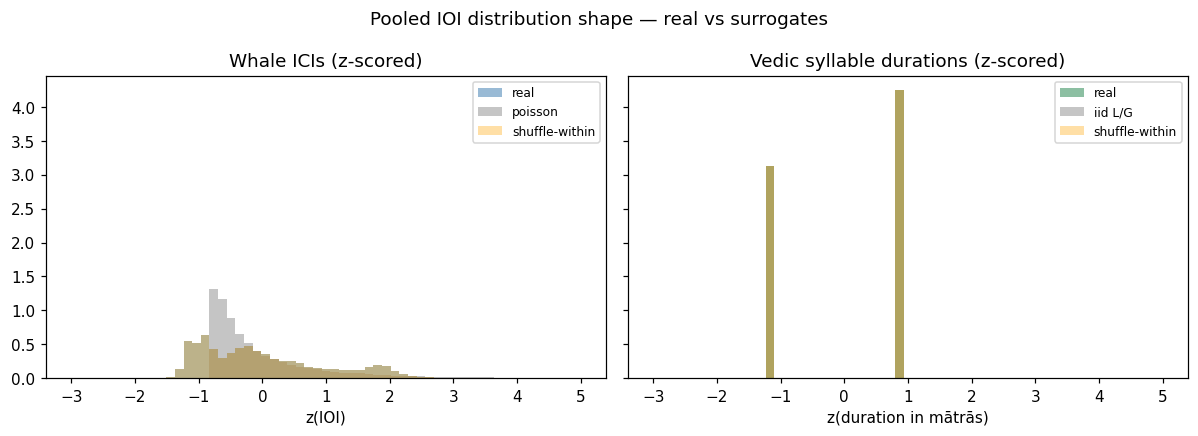

In [6]:
# Figure: pooled IOI histograms in z-units (shape comparison).
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
bins = np.linspace(-3, 5, 60)
axes[0].hist(pool_z["whale_real"], bins=bins, alpha=0.55, label="real", color="steelblue", density=True)
axes[0].hist(pool_z["whale_poisson"], bins=bins, alpha=0.45, label="poisson", color="grey", density=True)
axes[0].hist(pool_z["whale_within"], bins=bins, alpha=0.35, label="shuffle-within", color="orange", density=True)
axes[0].set_title("Whale ICIs (z-scored)")
axes[0].set_xlabel("z(IOI)")
axes[0].legend(fontsize=8)

axes[1].hist(pool_z["vedic_real"], bins=bins, alpha=0.55, label="real", color="seagreen", density=True)
axes[1].hist(pool_z["vedic_iid"], bins=bins, alpha=0.45, label="iid L/G", color="grey", density=True)
axes[1].hist(pool_z["vedic_within"], bins=bins, alpha=0.35, label="shuffle-within", color="orange", density=True)
axes[1].set_title("Vedic syllable durations (z-scored)")
axes[1].set_xlabel("z(duration in mātrās)")
axes[1].legend(fontsize=8)

fig.suptitle("Pooled IOI distribution shape — real vs surrogates")
fig.tight_layout()
fig.savefig(FIGURES / "03_pooled_ioi_histograms.png", bbox_inches="tight")
plt.show()


## 5. n-gram entropy

Whale ICIs are first quantized into 5 bins **per coda** (so the discretisation
is local, not corpus-wide), then 2-grams and 3-grams are tallied. Vedic uses
the natural L/G alphabet directly.

Lower entropy → more structured. We compare each corpus's real n-gram entropy
to its surrogates: a real value below all three surrogates indicates structure
beyond what the surrogate preserves.


In [7]:
def entropy_row(name, seqs, vedic_mode=False):
    if vedic_mode:
        h2 = features.vedic_ngram_entropy(seqs, n=2)
        h3 = features.vedic_ngram_entropy(seqs, n=3)
    else:
        h2 = features.whale_ngram_entropy(seqs, n=2, n_bins=5)
        h3 = features.whale_ngram_entropy(seqs, n=3, n_bins=5)
    return {"variant": name, "H_2gram": round(h2, 4), "H_3gram": round(h3, 4)}

ent_rows = [
    entropy_row("whale: real",            whale_ici),
    entropy_row("whale: shuffle-within",  whale_within),
    entropy_row("whale: shuffle-across",  whale_across),
    entropy_row("whale: poisson",         whale_poisson),
    entropy_row("vedic: real",            vedic_weights, vedic_mode=True),
    entropy_row("vedic: shuffle-within",  vedic_within,  vedic_mode=True),
    entropy_row("vedic: shuffle-across",  vedic_across,  vedic_mode=True),
    entropy_row("vedic: iid L/G",         vedic_iid,     vedic_mode=True),
]
ent_df = pd.DataFrame(ent_rows)
ent_df


,variant,H_2gram,H_3gram
0,whale: real,2.0381,3.1065
1,whale: shuffle-within,2.0956,3.1812
2,whale: shuffle-across,2.0903,3.1681
3,whale: poisson,2.0911,3.1723
4,vedic: real,1.9224,2.8380
5,vedic: shuffle-within,1.9657,2.9461
6,vedic: shuffle-across,1.9671,2.9506
7,vedic: iid L/G,1.9667,2.9496


In [8]:
# Chi-square on 2-gram counts: real vs each surrogate.
def _counts(seqs, vedic_mode):
    if vedic_mode:
        return features.ngram_counts(seqs, n=2)
    return features.ngram_counts(features.discretize_whale(seqs, n_bins=5), n=2)

whale_real_c     = _counts(whale_ici,     False)
whale_within_c   = _counts(whale_within,  False)
whale_across_c   = _counts(whale_across,  False)
whale_poisson_c  = _counts(whale_poisson, False)
vedic_real_c     = _counts(vedic_weights, True)
vedic_within_c   = _counts(vedic_within,  True)
vedic_across_c   = _counts(vedic_across,  True)
vedic_iid_c      = _counts(vedic_iid,     True)

chi_rows = []
for label, real, surr in [
    ("whale real vs shuffle-within",  whale_real_c, whale_within_c),
    ("whale real vs shuffle-across",  whale_real_c, whale_across_c),
    ("whale real vs poisson",         whale_real_c, whale_poisson_c),
    ("vedic real vs shuffle-within",  vedic_real_c, vedic_within_c),
    ("vedic real vs shuffle-across",  vedic_real_c, vedic_across_c),
    ("vedic real vs iid L/G",         vedic_real_c, vedic_iid_c),
]:
    chi2, p = swstats.chi2_ngram(real, surr)
    chi_rows.append({"comparison": label, "chi2": round(chi2, 2),
                     "p": "<1e-300" if p == 0 else f"{p:.2e}"})

pd.DataFrame(chi_rows)


,comparison,chi2,p
0,whale real vs shuffle-within,3532.83,<1e-300
1,whale real vs shuffle-across,4027.72,<1e-300
2,whale real vs poisson,3706.15,<1e-300
3,vedic real vs shuffle-within,10346.64,<1e-300
4,vedic real vs shuffle-across,16112.48,<1e-300
5,vedic real vs iid L/G,16446.03,<1e-300


## 6. Lag-k autocorrelation

In [9]:
def _ac(seqs):
    return features.mean_autocorrelation(seqs, max_lag=6)

ac_table = pd.DataFrame({
    "lag": np.arange(1, 7),
    "whale_real":     _ac(whale_ici),
    "whale_within":   _ac(whale_within),
    "whale_across":   _ac(whale_across),
    "whale_poisson":  _ac(whale_poisson),
    "vedic_real":     _ac(vedic_durations),
    "vedic_within":   _ac(vedic_dur_within),
    "vedic_across":   _ac(vedic_dur_across),
    "vedic_iid":      _ac(vedic_dur_iid),
}).set_index("lag").round(3)
ac_table


,whale_real,whale_within,whale_across,whale_poisson,vedic_real,vedic_within,vedic_across,vedic_iid
lag,,,,,,,,
1,0.126,-0.242,-0.247,-0.245,-0.254,-0.111,-0.111,-0.111
2,-0.359,-0.159,-0.159,-0.162,0.021,-0.095,-0.096,-0.092
3,-0.236,-0.090,-0.084,-0.082,-0.073,-0.080,-0.081,-0.083
4,-0.137,-0.062,-0.062,-0.067,-0.070,-0.065,-0.069,-0.068
5,-0.128,-0.047,-0.045,-0.046,-0.056,-0.055,-0.051,-0.055
6,-0.105,-0.035,-0.031,-0.038,-0.003,-0.042,-0.038,-0.039


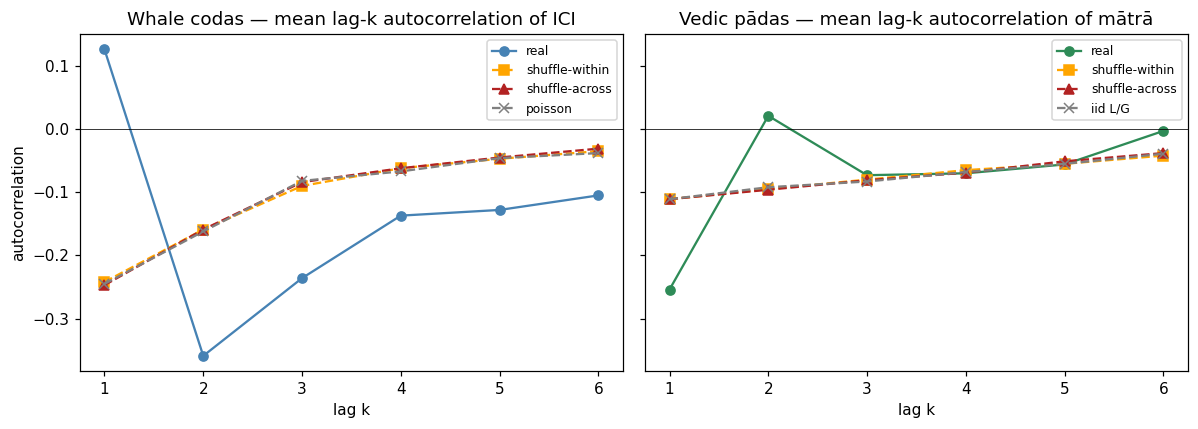

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
lags = np.arange(1, 7)
axes[0].plot(lags, ac_table["whale_real"],    "o-", label="real",          color="steelblue")
axes[0].plot(lags, ac_table["whale_within"],  "s--", label="shuffle-within", color="orange")
axes[0].plot(lags, ac_table["whale_across"],  "^--", label="shuffle-across", color="firebrick")
axes[0].plot(lags, ac_table["whale_poisson"], "x--", label="poisson",        color="grey")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Whale codas — mean lag-k autocorrelation of ICI")
axes[0].set_xlabel("lag k"); axes[0].set_ylabel("autocorrelation")
axes[0].legend(fontsize=8)

axes[1].plot(lags, ac_table["vedic_real"],    "o-", label="real",          color="seagreen")
axes[1].plot(lags, ac_table["vedic_within"],  "s--", label="shuffle-within", color="orange")
axes[1].plot(lags, ac_table["vedic_across"],  "^--", label="shuffle-across", color="firebrick")
axes[1].plot(lags, ac_table["vedic_iid"],     "x--", label="iid L/G",        color="grey")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Vedic pādas — mean lag-k autocorrelation of mātrā")
axes[1].set_xlabel("lag k")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / "03_autocorrelation.png", bbox_inches="tight")
plt.show()


## 7. Honest verdict

We expect surrogates to differ from real within each corpus — that is the
sanity check. The question that matters for "structural resonance" is
whether the **z-scored real whale ↔ real Vedic** distance is *smaller* than
the within-corpus real ↔ surrogate distances.

Numbers below let the reader judge for themselves; the README headline is
written from these.


In [11]:
# Within-corpus surrogate KS distances are computed on RAW (non-z-scored) pools
# because shuffle-within / shuffle-across preserve the per-corpus multiset
# exactly, so the only nontrivial within-corpus surrogate for KS is poisson.
def _ks(a, b):
    return swstats.ks_test(a, b)[0]

cross_D         = _ks(pool_z["whale_real"], pool_z["vedic_real"])
whale_within_D  = _ks(pool["whale_real"],   pool["whale_within"])
whale_across_D  = _ks(pool["whale_real"],   pool["whale_across"])
whale_poisson_D = _ks(pool["whale_real"],   pool["whale_poisson"])
vedic_within_D  = _ks(pool["vedic_real"],   pool["vedic_within"])
vedic_across_D  = _ks(pool["vedic_real"],   pool["vedic_across"])
vedic_iid_D     = _ks(pool["vedic_real"],   pool["vedic_iid"])

print("KS distance:")
print(f"  whale_real ↔ vedic_real (z-scored)    : {cross_D:.3f}")
print(f"  whale_real ↔ whale_shuffle_within     : {whale_within_D:.3f}")
print(f"  whale_real ↔ whale_shuffle_across     : {whale_across_D:.3f}")
print(f"  whale_real ↔ whale_poisson            : {whale_poisson_D:.3f}")
print(f"  vedic_real ↔ vedic_shuffle_within     : {vedic_within_D:.3f}  (multiset preserved → 0)")
print(f"  vedic_real ↔ vedic_shuffle_across     : {vedic_across_D:.3f}  (multiset preserved → 0)")
print(f"  vedic_real ↔ vedic_iid                : {vedic_iid_D:.3f}")

# The honest signal is whether the cross-corpus z-scored distance is below the
# within-corpus distances on the *non-trivial* surrogates (poisson/iid), since
# the shuffle surrogates trivially preserve the IOI multiset.
nontrivial_floor = max(whale_poisson_D, vedic_iid_D)
print(f"\nNon-trivial within-corpus surrogate KS floor: {nontrivial_floor:.3f}")
print(f"Cross-corpus distance:                         {cross_D:.3f}")
if cross_D < nontrivial_floor:
    print("\n→ STRUCTURAL RESONANCE SIGNAL on pooled-IOI shape: cross-corpus distance "
          "is smaller than each corpus's distance to its own structure-destroying null.")
else:
    print("\n→ NO STRUCTURAL RESONANCE on pooled-IOI shape: real whale ↔ real Vedic "
          "distributions differ by more than each corpus differs from its own poisson/iid null.")

# n-gram entropy gap (real vs strongest surrogate) — a positive gap means the
# corpus has structure beyond what shuffling preserves.
print()
print("n-gram entropy structure gap (smaller real H = more structure than null):")
print(f"  whale H(real)−H(within) = {ent_df.iloc[0]['H_2gram'] - ent_df.iloc[1]['H_2gram']:+.4f} bits")
print(f"  vedic H(real)−H(within) = {ent_df.iloc[4]['H_2gram'] - ent_df.iloc[5]['H_2gram']:+.4f} bits")


KS distance:
  whale_real ↔ vedic_real (z-scored)    : 0.374
  whale_real ↔ whale_shuffle_within     : 0.000
  whale_real ↔ whale_shuffle_across     : 0.000
  whale_real ↔ whale_poisson            : 0.224
  vedic_real ↔ vedic_shuffle_within     : 0.000  (multiset preserved → 0)
  vedic_real ↔ vedic_shuffle_across     : 0.000  (multiset preserved → 0)
  vedic_real ↔ vedic_iid                : 0.000

Non-trivial within-corpus surrogate KS floor: 0.224
Cross-corpus distance:                         0.374

→ NO STRUCTURAL RESONANCE on pooled-IOI shape: real whale ↔ real Vedic distributions differ by more than each corpus differs from its own poisson/iid null.

n-gram entropy structure gap (smaller real H = more structure than null):
  whale H(real)−H(within) = -0.0575 bits
  vedic H(real)−H(within) = -0.0433 bits
